Step 1: Install the required libraries:
langgraph → Framework to build AI agents using graphs.
langchain → Provides prompts, chains, parsers, etc.
langchain-core → Core abstractions like messages and prompt templates.
langchain-google-genai → Connects LangChain to Google's Gemini models.


In [5]:
!pip install -q langgraph langchain langchain-core langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.7 MB/s eta 0:00:00


Step 2: Connect Gemini Securely


In [7]:
# Import modules
from google.colab import userdata
import os

# Load the groq from Colab Secrets
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

Step 3: Create the Gemini LLM


In [9]:
# Import the Groq wrapper provided by LangChain
from langchain_groq import ChatGroq

# Create an LLM object
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)
print(llm)

metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.13'}} output_version=None profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True} client=<groq.resources.chat.completions.Completions object at 0x7bebdcf38230> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7bebdce1d6a0> model_name='openai/gpt-oss-20b' temperature=1e-08 model_kwargs={} groq_api_key=SecretStr('**********') groq_api_base=None groq_proxy=None


Your First LLM Call using invoke()

In [10]:
# Ask Gemini a simple question
response = llm.invoke("What is Artificial Intelligence?")

# Print the complete response object
print(response)

content='**Artificial Intelligence (AI)** is the field of computer science that seeks to create systems capable of performing tasks that normally require human intelligence. These tasks include:\n\n| Task | Typical Human Skill | AI Approach |\n|------|---------------------|-------------|\n| Recognizing speech | Listening & interpreting | Speech‑to‑text models |\n| Understanding language | Reading & comprehension | Natural‑language processing |\n| Seeing & interpreting images | Visual perception | Computer vision |\n| Making decisions | Reasoning & judgment | Decision‑making algorithms |\n| Learning from experience | Adaptation | Machine learning / deep learning |\n\n### Core Ideas\n\n1. **Representation** – How information is encoded (e.g., numbers, graphs, symbolic rules).  \n2. **Reasoning** – Drawing conclusions or making predictions from data.  \n3. **Learning** – Improving performance over time by adjusting internal parameters.  \n4. **Perception** – Interpreting raw sensory data 

Step 5: Create the State
LangGraph recommends TypedDict because

better readability
type checking
editor autocomplete
every node knows what fields exist

In [11]:
from typing_extensions import TypedDict

# Shared memory of our AI Agent
class State(TypedDict):
    application: str
    experience_level: str
    skill_match: str
    response: str

Step 6: Create the Workflow (Graph)

In [12]:
# Import the required classes from LangGraph
from langgraph.graph import StateGraph, START, END

# Create an empty workflow (graph) using our State schema
workflow = StateGraph(State)

Step 7: Add the First Node

In [13]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def categorize_experience(state: State) -> State:
    """
    Node 1
    Categorizes the candidate's experience level.
    """

    print("\n===== Categorizing Experience =====")

    prompt = ChatPromptTemplate.from_template(
        """
        You are an HR recruiter.

        Read the following application.

        Application:
        {application}

        Categorize the candidate into ONLY one category:

        Entry-level
        Mid-level
        Senior-level

        Respond with ONLY the category name.
        """
    )

    parser = StrOutputParser()

    chain = prompt | llm | parser

    experience_level = chain.invoke({
        "application": state["application"]
    })

    print("Experience Level :", experience_level)

    return {
        "experience_level": experience_level
    }

In [14]:
def assess_skillset(state: State) -> State:
    """
    Node 2
    Checks whether the candidate matches a Python Developer role.
    """

    print("\n===== Assessing Skillset =====")

    prompt = ChatPromptTemplate.from_template(
        """
        You are an HR recruiter.

        The job role is Python Developer.

        Read the following application.

        Application:
        {application}

        If the candidate has strong Python skills,
        respond with ONLY:

        Match

        Otherwise respond with ONLY:

        No Match
        """
    )

    parser = StrOutputParser()

    chain = prompt | llm | parser

    skill_match = chain.invoke({
        "application": state["application"]
    })

    print("Skill Match :", skill_match)

    return {
        "skill_match": skill_match
    }

In [15]:
def schedule_hr_interview(state: State) -> State:
    """
    Node 3
    Candidate is shortlisted.
    """

    print("\n===== Scheduling HR Interview =====")

    return {
        "response": "Candidate has been shortlisted for an HR interview."
    }

In [16]:
def escalate_to_recruiter(state: State) -> State:
    """
    Node 4
    Candidate is senior but doesn't match the required skills.
    """

    print("\n===== Escalating to Recruiter =====")

    return {
        "response": "Candidate has senior-level experience but does not match the required skills. Escalating to recruiter."
    }

In [17]:
def reject_application(state: State) -> State:
    """
    Node 5
    Candidate is rejected.
    """

    print("\n===== Rejecting Candidate =====")

    return {
        "response": "Candidate does not meet the job requirements."
    }

In [18]:
# Register all functions as nodes in the graph

workflow.add_node("categorize_experience", categorize_experience)

workflow.add_node("assess_skillset", assess_skillset)

workflow.add_node("schedule_hr_interview", schedule_hr_interview)

workflow.add_node("escalate_to_recruiter", escalate_to_recruiter)

workflow.add_node("reject_application", reject_application)

Step 10: Create the Routing Function (The Brain)

In [19]:
def route_app(state: State) -> str:
    """
    Decides which node should execute next based on
    the current state.
    """

    # If the candidate matches the required skills
    if state["skill_match"] == "Match":
        return "schedule_hr_interview"

    # Candidate is senior but doesn't match the skills
    elif state["experience_level"] == "Senior-level":
        return "escalate_to_recruiter"

    # Everyone else is rejected
    else:
        return "reject_application"

Step 11: Add the Edges

In [20]:
# Step 1: Connect START to the first node
workflow.add_edge(START, "categorize_experience")

# Step 2: After categorizing experience,
# go to assess skillset
workflow.add_edge(
    "categorize_experience",
    "assess_skillset"
)

# Step 3: After assessing skills,
# use the routing function to decide
# the next node
workflow.add_conditional_edges(
    "assess_skillset",
    route_app
)

# Step 4: These are terminal nodes
workflow.add_edge(
    "schedule_hr_interview",
    END
)

workflow.add_edge(
    "escalate_to_recruiter",
    END
)

workflow.add_edge(
    "reject_application",
    END
)

Step 12: Compile the Graph

In [21]:
# Compile the workflow into an executable graph
app = workflow.compile()

Step 13: Visualize the Graph

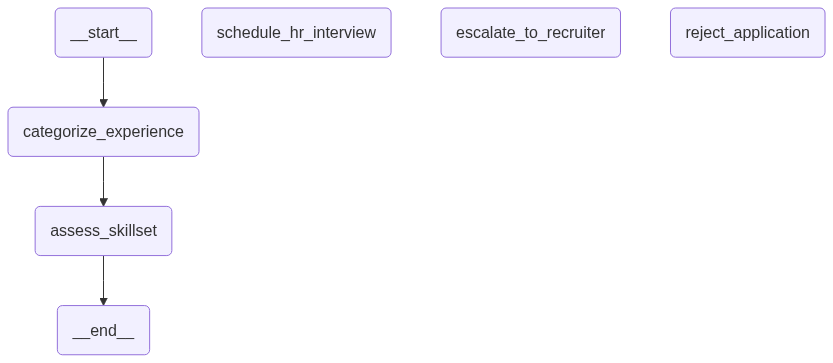

In [22]:
from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

Step 14: Create a function to execute the agent

In [23]:
def run_candidate_screening(application: str):
    """
    Executes the LangGraph workflow for a candidate application.
    """

    result = app.invoke({
        "application": application
    })

    return {
        "experience_level": result["experience_level"],
        "skill_match": result["skill_match"],
        "response": result["response"]
    }

Step 15: Test the AI Agent

In [26]:
application_text = """
I have 1 years of experience as a c++ Developer.
I have worked with Python, Django, Flask, FastAPI,
SQL, Docker and AWS.
"""

result = run_candidate_screening(application_text)

print("\n===== FINAL RESULT =====")
print("Experience Level :", result["experience_level"])
print("Skill Match      :", result["skill_match"])
print("Response         :", result["response"])


===== Categorizing Experience =====
Experience Level : Entry-level

===== Assessing Skillset =====
Skill Match : No Match

===== Rejecting Candidate =====

===== FINAL RESULT =====
Experience Level : Entry-level
Skill Match      : No Match
Response         : Candidate does not meet the job requirements.
